## Autora: Quezia Tedeschi

# Case Crédito Privado

# Sumário
- [Objetivo do case](#Objetivo-do-case)
- [Bases utilizadas](#Bases-utilizadas)




## Objetivo do case
Analisar fundos com exposição a debêntures.

## Bases utilizadas
### Carteira
Link: https://dados.cvm.gov.br/dataset/fi-doc-cda
* Períodos selecionados: Jan/2025, Jul/2025, Jan/2026, Mar/2026

### Informe Diário
Link:
Período selecionado: Jan/2026 a Mar/2026




### Bibliotecas

In [43]:
import requests
import zipfile
import io
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import unicodedata


### Constantes e variáveis

In [44]:
nucleo = Path().resolve()
diretorio_dados = nucleo / "dados"

## URL base da carteira
url_carteira = "https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_{}.zip"
## períodos selecionados da carteira
periodo_carteira = [202501, 202506, 202601,202602]
# pasta dados carteira
pasta_carteira = diretorio_dados / "dados_carteira"
# prefixo carteira
prefixo_carteira = "cda_fi"

## URL base de informs diário
url_inf_diario = "https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_{}.zip"
## períodos selecionados do informe diário
periodo_inf_diario = [202601,202602,202603]
# pasta dados informe diário
pasta_inf_diario = diretorio_dados / "dados_inf_diario"
# prefixo informe diário
prefixo_inf_diario = "inf_diario_fi"

## Debêntures
arquivo_deb = "Debentures.com.br_Caracteristica_em_27-03-2026_as_08-48-24.xls"


## Anbima
arquivo_anbima = "ativos_anbima_202603271546.csv"


### Funções

In [45]:
def baixar_e_extrair(url_base, periodos, pasta_destino, prefixo_arquivo):
    """
    Realiza o download de arquivos compactados (.zip) a partir de uma URL parametrizada por período,
    e executa a extração diretamente em memória, sem persistir o arquivo zip em disco.

    Para cada período informado, a função:
    - constrói a URL final substituindo o placeholder na url_base
    - realiza o download do conteúdo via requisição HTTP
    - descompacta o arquivo diretamente da memória (BytesIO)
    - salva os arquivos extraídos em uma pasta específica por período

    Parâmetros
    ----------
    url_base : str
        URL base contendo um placeholder '{}' para inserção do período.
        Exemplo: 'https://.../cda_fi_{}.zip'

    periodos : list[int] ou list[str]
        Lista de períodos a serem processados (ex: [202501, 202502, ...])

    pasta_destino : str
        Diretório onde os arquivos extraídos serão armazenados

    prefixo_arquivo : str
        Prefixo utilizado na criação das pastas de saída por período

    Retorno
    -------
    None

    Observações
    ----------
    - A extração é feita diretamente da memória, evitando escrita intermediária do arquivo zip em disco
    - Cada período gera uma subpasta independente, evitando sobrescrita de arquivos
    - Em caso de falha no download ou extração, a função exibe mensagens de erro no console
    """
    pasta_destino = Path(pasta_destino)
    pasta_destino.mkdir(parents = True, exist_ok = True)
    
    for periodo in periodos:
        
        url = url_base.format(periodo)
        pasta_periodo = pasta_destino / f"{prefixo_arquivo}_{periodo}"
        pasta_periodo.mkdir(pasta_periodo, exist_ok=True)

        print(f"Baixando e extraindo: {url}")

        try:
            response = requests.get(url, timeout=60)

            if response.status_code == 200:
                with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                    zip_ref.extractall(pasta_periodo)
                print(f"Pronto - extraído em: {pasta_periodo}")

            else:
                print(f"Erro {response.status_code} - {url}")

        except Exception as e:
            print(f"Erro: {url} -> {e}")
    print(f"Download e extração concluídos para {len(periodos)} períodos.")

def encontrar_concorrente(df_base_concorrentes, df_base_referencia, fundo_nome):
    fundo_ref = (
        df_base_referencia
        .reset_index()
        .rename(columns={"index": "DENOM_SOCIAL"})
    )

    fundo_ref = fundo_ref[fundo_ref["DENOM_SOCIAL"] == fundo_nome].iloc[0]
    score_ref = fundo_ref["SCORE_RISCO"]

    df_temp = df_base_concorrentes.copy()
    df_temp["DISTANCIA_SCORE"] = (df_temp["SCORE_RISCO"] - score_ref).abs()

    concorrente = df_temp.sort_values("DISTANCIA_SCORE").iloc[0]

    return concorrente

def importar_arquivos_csv(arquivos):
    print(f"{len(arquivos)} arquivos encontrados")

    dfs = []
    for arquivo in arquivos:
    
        periodo = arquivo.stem.split("_")[-1]
    
        df = pd.read_csv( 
            arquivo,
            sep = ';',
            encoding = 'latin1',
            decimal = ',',
            low_memory = False)
        
        df["PERIODO"] = periodo
        
        dfs.append(df)
    
    df = pd.concat(dfs, ignore_index = True)
    return df


def classificar_indexador(valor):
    
    if pd.isna(valor):
         
        return "NÃO INFORMADO"
        
    valor = valor.upper().strip()

    if  "IPCA" in valor:
        return "IPCA"
    elif "CDI" in valor or "DI" in valor:
        return "CDI"
    elif "IGP" in valor:
        return "IGP"
    elif "SELIC" in valor:
        return "SELIC"
    elif "PRE" in valor or "PREFIX" in valor:
        return "PRE"
    else:
        return "OUTROS"

def classificar_setor(emissor):
    emissor = str(emissor).upper()
    
    # Energia
    if any(x in emissor for x in ["ENERG", "ELETRO", "CPFL", "EDP", "ENGIE", "COELCE", "CEMIG", "NEOENERGIA"]):
        return "Energia"
    
    # Saneamento
    elif any(x in emissor for x in ["SANEAMENTO", "AGUA", "SABESP", "COPASA", "CAGECE", "CORSAN", "IGUA", "AEGEA"]):
        return "Saneamento"
    
    # Rodovias / Infraestrutura
    elif any(x in emissor for x in ["RODOVIA", "CONCESSIONARIA", "ECORODOVIAS", "AUTOPISTA", "ROTA", "COLINAS"]):
        return "Infraestrutura"
    
    # Telecom
    elif any(x in emissor for x in ["TELECOM", "FIBRA", "TELEFONICA", "TIM", "ALGAR", "BRISANET"]):
        return "Telecom"
    
    # Logística / Transporte
    elif any(x in emissor for x in ["LOGISTICA", "TRANSPORT", "VLI", "MRS"]):
        return "Logística"
    
    # Saúde
    elif any(x in emissor for x in ["SAUDE", "DOR", "HAPVIDA", "DIAGNOSTICOS"]):
        return "Saúde"
    
    # Financeiro
    elif any(x in emissor for x in ["SECURITIZADORA", "VERT", "OPEA", "TRAVESSIA"]):
        return "Financeiro"
    
    # Consumo / Varejo
    elif any(x in emissor for x in ["LOJAS", "RENNER", "SENDAS", "DROGASIL", "SMARTFIT"]):
        return "Consumo"
    
    # Industrial / Materiais
    elif any(x in emissor for x in ["CIMENTO", "VOTORANTIM", "SUZANO", "BRASKEM"]):
        return "Industrial"
    
    else:
        return "Outros"
    

In [105]:
## Download e Extração dos arquivos de Carteira e Informe Diário
baixar_e_extrair(
    url_base = url_carteira,
    periodos = periodo_carteira,
    pasta_destino = pasta_carteira,
    prefixo_arquivo = prefixo_carteira
)

baixar_e_extrair(
    url_base = url_inf_diario,
    periodos = periodo_inf_diario,
    pasta_destino = pasta_inf_diario,
    prefixo_arquivo = prefixo_inf_diario
)

AttributeError: 'WindowsPath' object has no attribute 'makedirs'

# Encontrar elenco de análise utilizando a base do CDA

Objetivo é encontrar 2 (dois) fundos da Icatu Vanguarda e depois dois respectivos concorrentes. Para isso, será utilizado os arquivos do CDA, cujo filtro são fundos que possuem debêntures associados. 

Conforme visto abaixo, os arquivos BLC_4 e BLC_6 possuem TP_ATIVO com debêntures. A partir desses dois arquivos importados, foi escolhido um conjunto de colunas que retratam desde a identificação do fundo até as características financeiras dele. Mais adiante, está disponível essas colunas de interesse da carteira segregadas pelo objetivo macro delas.

In [46]:
# Descobrindo qual dos arquivos do CDA contém as debêntures
for i in range(1, 9):
    arquivo = list(pasta_carteira.glob(f"cda_fi_*/cda_fi_BLC_{i}_*.csv"))
    
    if arquivo:
        df_temp = pd.read_csv(arquivo[0], sep=';', encoding='latin1', nrows=1000)
        print(f"\nBLC_{i}")
        print(df_temp["TP_ATIVO"].unique())


BLC_1
['Título público federal']

BLC_2
['Fundo de Investimento e de Cotas' 'FIDC' 'FI Imobiliário'
 'FI Participações' 'Fundos de Índice']

BLC_3
['SWAP']

BLC_4
['Debênture simples' 'Debênture Permutável' 'Bônus de subscrição'
 'Ação ordinária' 'BDR não patrocinado' 'BDR de ETF' 'Ação preferencial'
 'Debênture conversível' 'Certificado de depósito de ações'
 'Recibo de subscrição']

BLC_5
['Letra Financeira' 'CDB/ RDB' 'CDB Vinculado' 'DPGE']

BLC_6
['Debênture simples' 'Nota Promissória/ Commercial Paper/ Export Note'
 'CRA' 'Debênture conversível' 'CCB' 'NCA']

BLC_7
['Fundos Offshore' 'Ação ordinária' 'Bonds e Treasury' 'Outros'
 'Ação preferencial']

BLC_8
['Outros' 'Contrato Futuro' 'Ação ordinária'
 'Certificado de recebíveis imobiliários'
 'Outros Certificados de Recebíveis' 'Opção de compra' 'Opção de venda'
 'Futuro de DI1:DI de 1 dia' 'Futuro de DAP:Cupom de DI x IPCA'
 'Bônus de subscrição' 'Fundos de Índice' 'Recibo de subscrição'
 'Ação ou recibo de ação do Mercosul']


In [47]:
# Importação de todos os BLC_4 e BLC_6 baixados
arquivos_bcl_4 = list(pasta_carteira.glob("cda_fi_*/cda_fi_BLC_4_*.csv"))
arquivos_bcl_6 = list(pasta_carteira.glob("cda_fi_*/cda_fi_BLC_6_*.csv"))
arquivos = arquivos_bcl_4 + arquivos_bcl_6

df_cda = importar_arquivos_csv(arquivos = arquivos)

# Trazendo apenas as linhas referentes ao tipo de ativo Debênture
df_cda_deb = df_cda[df_cda["TP_ATIVO"].str.contains("Debênture", case = False, na = False)]

8 arquivos encontrados


## Seleção das colunas do CDA interessantes para o case
### Identificação do fundo
* CNPJ_FUNDO_CLASSE
* DENOM_SOCIAL
### Tempo
* DT_COMPTC
* PERIODO * inserido na etapa de importação
### Identificação do ativo
* CD_ATIVO
* DS_ATIVO
* CD_ISIN
* TITULO_CETIP
### Emissor
* PF_PJ_EMISSOR
* CPF_CNPJ_EMISSOR
* EMISSOR
### Posição do fundo
* QT_POS_FINAL
* VL_MERC_POS_FINAL
* VL_CUSTO_POS_FINAL
### Características financeiras
* DT_VENC
* CD_INDEXADOR_POSFX
* DS_INDEXADOR_POSFX
* PR_INDEXADOR_POSFX
* PR_CUPOM_POSFX
* PR_TAXA_PREFX

In [48]:
# Filtrando cda com as colunas de interesse
colunas_carteira = ["CNPJ_FUNDO_CLASSE",
    "DENOM_SOCIAL",
    "DT_COMPTC",
    "TP_ATIVO",
    "CD_ATIVO",
    "DS_ATIVO",
    "CD_ISIN",
    "EMISSOR",
    "CPF_CNPJ_EMISSOR",
    "QT_POS_FINAL",
    "VL_MERC_POS_FINAL",
    "VL_CUSTO_POS_FINAL",
    "DT_VENC",
    "DS_INDEXADOR_POSFX",
    "PR_INDEXADOR_POSFX",
    "PR_CUPOM_POSFX",
    "PR_TAXA_PREFX",
    "PERIODO"]

df_cda_final = df_cda_deb[colunas_carteira].copy()

# Identificando perfil do fundo 

Nesta etapa, para a identificação de dois perfis distintos, isto é, um fundo da Icatu Vanguarada mais conservador (maior diversificação da carteira e menor concentração por emissor) e outro mais arriscado (menor diversificação da carteira e maior concentração por emissor), foi construido um score simplificado de risco com base em três métricas calculadas a partir dos dados da carteira (CDA): concentração máxima por emissor, número de emissores e número de ativos. A primeira métrica, concentração máximo por emissor, recebeu o maior peso de 0,6, pois demonstra diretamente a relação de dependência entre fundo e emissor específico. Já as outras duas receberam peso no valor de 0,2 cada, pois estão atreladas a diversificação que reduz o score conforme a carteira se mostra mais pulverizada. Vale ressaltar, que foi optado pela normalização das variáveis permitindo a comparabilidade entre as métricas com escalas distintas, além de tornar o ranqueamento automático e aplicável para os concorrentes. 

Para evitar distorções na análise devido a baixa diversificação da carteira por limitação estrutural e não por estratégia, foi inserido um filtro utilizando as métricas número de emissor (acima de dois emissores) e número de ativos (acima de 50 ativos). 

Em uma análise prévia realizada mais adiante sobre a perfomance do fundo, utilizando a base do Informe Diário, constatou-se a a necessidade de retirada de dois fundos, um da Icatu Vanguarda e outro do conjunto de Concorrentes, pois não apresentavam dados ou dados inconsistentes. Os fundos mencionados são, respectivamente, ICATU VANGUARDA IPORÃ PG FIF CLASSE DE INVESTIMENTO MULTIMERCADO CRED PRIV - RESP LIMITADA e RIO DEBÊNTURES FUNDO INCENTIVADO DE INVESTIMENTO FINANCEIRO EM INFRAESTRUTURA RENDA FIXA.

Por fim, a seleção dos concorrentes é análoga ao ranqueamento produzido para a Icatu Vanguarda, com a adição da metodologia de comparação direta entre os fundos (Icatu Vanguarda e Concorrente) utilizando a proximidade dos scores como forma de identificação de perfis parecidos.

In [49]:
df_cda_base = df_cda_final.copy()

# Alterando o tipo da coluna para fins de cálculo
df_cda_base["VL_MERC_POS_FINAL"] = pd.to_numeric(
    df_cda_base["VL_MERC_POS_FINAL"],
    errors="coerce")

# Concentração por emissor: soma do valor de mercado dos ativos do emissor/patrimônio total da carteira
df_emissor = (df_cda_base.groupby(["DENOM_SOCIAL", "EMISSOR", "CNPJ_FUNDO_CLASSE"])["VL_MERC_POS_FINAL"].sum().reset_index())
## total por fundo
df_total = (df_cda_base.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["VL_MERC_POS_FINAL"].sum().reset_index(name="TOTAL_FUNDO"))
## % dentro do fundo
df_emissor = df_emissor.merge(df_total, on=["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])
df_emissor["PCT"] = df_emissor["VL_MERC_POS_FINAL"] / df_emissor["TOTAL_FUNDO"]
### portanto, maior concentração por emissor
df_concentracao = (df_emissor.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["PCT"].max())

# número de emissores
df_div = (df_cda_base.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["EMISSOR"].nunique())

# número de ativos
df_ativos = (df_cda_base.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["CD_ISIN"].nunique())

# Consolidando
df_resumo = pd.concat([df_concentracao, df_div, df_ativos], axis = 1)
df_resumo.columns = ["MAX_CONCENTRACAO", "QTD_EMISSORES", "QTD_ATIVOS"]

In [50]:
df_rank = df_resumo.copy()

# Filtro de diversificação
df_rank = df_rank[
    (df_rank["QTD_EMISSORES"] > 2) & 
    (df_rank["QTD_ATIVOS"] > 50) 
]

# normalização simples (escala comparável)
df_rank["CONC_NORM"] = df_rank["MAX_CONCENTRACAO"] / df_rank["MAX_CONCENTRACAO"].max()
df_rank["EMISSOR_NORM"] = df_rank["QTD_EMISSORES"] / df_rank["QTD_EMISSORES"].max()
df_rank["ATIVO_NORM"] = df_rank["QTD_ATIVOS"] / df_rank["QTD_ATIVOS"].max()

# score de risco (quanto maior, mais arriscado)
df_rank["SCORE_RISCO"] = (
    df_rank["CONC_NORM"] * 0.6   # peso maior (principal fator)
    + (1 - df_rank["EMISSOR_NORM"]) * 0.2
    + (1 - df_rank["ATIVO_NORM"]) * 0.2
)


# Concorrentes - retirada de qualquer Icatu
df_comp = df_rank.reset_index().rename(columns={"index": "DENOM_SOCIAL"}).copy()

df_comp = df_comp[
    ~df_comp["DENOM_SOCIAL"].str.contains("icatu", case=False, na=False)
].copy()

## Retirada de concorrentes não factíveis ao analisar o Informe Diário
df_comp = df_comp[~df_comp["CNPJ_FUNDO_CLASSE"].str.contains("54.909.880/0001-42", case = False, na = False)].copy()

# Opções de fundos da Icatu Vanguarda
df_cda_iv = df_rank.reset_index().rename(columns={"index": "DENOM_SOCIAL"}).copy()
df_cda_iv = df_cda_iv[df_cda_iv["DENOM_SOCIAL"].str.contains("icatu vanguarda", case = False, na = False)].copy()

## Retirada de Icatu Vanguarda não factível ao analisar o informe diário
df_cda_iv = df_cda_iv[~df_cda_iv["CNPJ_FUNDO_CLASSE"].str.contains("35.609.382/0001-30", case = False, na = False)].copy()

## Top 3 mais arriscados da Icatu Vanguarda
top_risco = df_cda_iv.sort_values("SCORE_RISCO", ascending=False).head(3)

## Top 3 mais conservadores
top_conservador = df_cda_iv.sort_values("SCORE_RISCO", ascending=True).head(3)

# Dois representantes da Icatu Vanguarda
fundo_conservador = top_conservador["DENOM_SOCIAL"].iloc[0]
fundo_arriscado = top_risco["DENOM_SOCIAL"].iloc[0]

## Respectivos concorrentes dos fundos representantes da Icatu Vanguarda
conc_conservador = encontrar_concorrente(df_comp, df_rank, fundo_conservador)
conc_arriscado = encontrar_concorrente(df_comp, df_rank, fundo_arriscado)


## Perfil mais arriscado
O fundo ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPRIV PREV - RESP LIMITADA apresenta a maior concentração por emissor da amostra, o que domina as demais métricas e o posiciona como o fundo mais arriscado em termos de exposição ao risco de crédito. E o seu concocorrente, por proximidade de score, é o ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF MULT CRÉD PRIV RESP LIMITADA.

In [51]:
cnpj_iv_risco = top_risco["CNPJ_FUNDO_CLASSE"].iloc[0]
cnpj_conc_risco = conc_arriscado["CNPJ_FUNDO_CLASSE"]

exibir_arriscado = pd.DataFrame((top_risco.iloc[0], conc_arriscado))
exibir_arriscado = exibir_arriscado.fillna("-").reset_index(drop=True)

#### Perfil mais arriscado - Icatu Vanguarda x Concorrente mais próximo

In [52]:
exibir_arriscado

,DENOM_SOCIAL,CNPJ_FUNDO_CLASSE,MAX_CONCENTRACAO,QTD_EMISSORES,QTD_ATIVOS,CONC_NORM,EMISSOR_NORM,ATIVO_NORM,SCORE_RISCO,DISTANCIA_SCORE
0,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,53.444.176/0001-07,0.018537,4,122,0.177485,0.064516,0.283721,0.436843,-
1,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,58.013.738/0001-73,0.014084,3,65,0.134843,0.048387,0.151163,0.440996,0.004152


## Perfil mais conservador
O fundo ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE INVESTIMENTO RF CRED PRIV PREVIDENCIÁRIO - RESP  LTDA apresenta o menor nível de concentração por emissor, aliado a uma carteira com elevado número de ativos, caracterizando perfil mais conservador em termos de risco de crédito. O fundo JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM INVEST EM DEB DE INFRA RF CRÉD PRIV - RESP LIMITADA é o seu concorrente por proximação de score de risco.

In [53]:
cnpj_iv_conservador = top_conservador["CNPJ_FUNDO_CLASSE"].iloc[0]
cnpj_conc_conservador = conc_conservador["CNPJ_FUNDO_CLASSE"]

exibir_conservador = pd.DataFrame((top_conservador.iloc[0], conc_conservador))
exibir_conservador = exibir_conservador.fillna("-").reset_index(drop=True)

#### Perfil mais conservador - Icatu Vanguarda x Concorrente mais próximo

In [54]:
exibir_conservador

,DENOM_SOCIAL,CNPJ_FUNDO_CLASSE,MAX_CONCENTRACAO,QTD_EMISSORES,QTD_ATIVOS,CONC_NORM,EMISSOR_NORM,ATIVO_NORM,SCORE_RISCO,DISTANCIA_SCORE
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,34.081.211/0001-18,0.009074,6,165,0.086876,0.096774,0.383721,0.356027,-
1,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,54.834.372/0001-42,0.013540,4,234,0.129638,0.064516,0.544186,0.356043,0.000016


In [55]:
# Portanto, os fundos escolhidos:
fundos_escolhidos = [cnpj_iv_risco, cnpj_conc_risco, cnpj_iv_conservador, cnpj_conc_conservador]

df_cda_4 = df_cda_final[df_cda_final["CNPJ_FUNDO_CLASSE"].isin(fundos_escolhidos)]

# Para integrar o nome do fundo a partor do cda na base do informe diário por meio do cnpj
df_cda_4_aux = df_cda_4[["CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL"]].copy()
df_cda_4_aux = df_cda_4_aux.drop_duplicates(subset=["CNPJ_FUNDO_CLASSE"])

# Importação os dados de informe diário
arquivos_inf_diario = list(pasta_inf_diario.glob("inf_diario_fi_*/inf_diario_fi_*.csv"))

df_inf_diario = importar_arquivos_csv(arquivos_inf_diario)

df_inf_diario_aux = df_inf_diario[df_inf_diario["CNPJ_FUNDO_CLASSE"].isin(fundos_escolhidos)]
colunas_inf_diario = ["CNPJ_FUNDO_CLASSE", "DT_COMPTC", "VL_TOTAL", "VL_QUOTA", "VL_PATRIM_LIQ", "PERIODO"] 

df_inf_diario_4 = df_inf_diario_aux[colunas_inf_diario].copy()

# Integraçã entre cda e informe diário
df_inf_diario_4 = df_inf_diario_4.merge(
    df_cda_4_aux[["CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL"]],
    how="left",
    on="CNPJ_FUNDO_CLASSE"
)

3 arquivos encontrados


# Performance dos fundos utilizando o Informe Diário

Nesta primeira etapa, foi realizada a análise de performance dos quatro fundos selecionados com base no Informe Diário da CVM, considerando o período de janeiro a março de 2026. O objetivo é comparar a evolução da cota, o retorno acumulado e o patrimônio líquido dos fundos, estabelecendo uma visão inicial de comportamento e porte antes da análise de composição de carteira.

In [56]:
# removendo registros invalidos e ordenando pelo cnpj do fundo e data de competência
df_inf = df_inf_diario_4.dropna(subset=["DT_COMPTC", "VL_TOTAL", "VL_PATRIM_LIQ"])
df_inf = df_inf_diario_4.sort_values(["CNPJ_FUNDO_CLASSE", "DT_COMPTC"]).reset_index(drop=True)

## alterando o tipo do dado
df_inf["VL_QUOTA"] = pd.to_numeric(
    df_inf["VL_QUOTA"],
    errors="coerce")

df_inf["VL_PATRIM_LIQ"] = pd.to_numeric(
    df_inf["VL_PATRIM_LIQ"],
    errors="coerce")

# Métricas para avaliar a performance
## Retorno diário - variação real
df_inf["RETORNO_DIARIO"] = (
    df_inf.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"].pct_change()
)

## Normalizando a cota - para fins de comparação
df_inf["COTA_BASE_100"] = (
    df_inf.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"]
          .transform(lambda s: s / s.iloc[0] * 100)
)
## Retorno acumulado 
df_inf["RETORNO_ACUMULADO"] = df_inf["COTA_BASE_100"] / 100 - 1

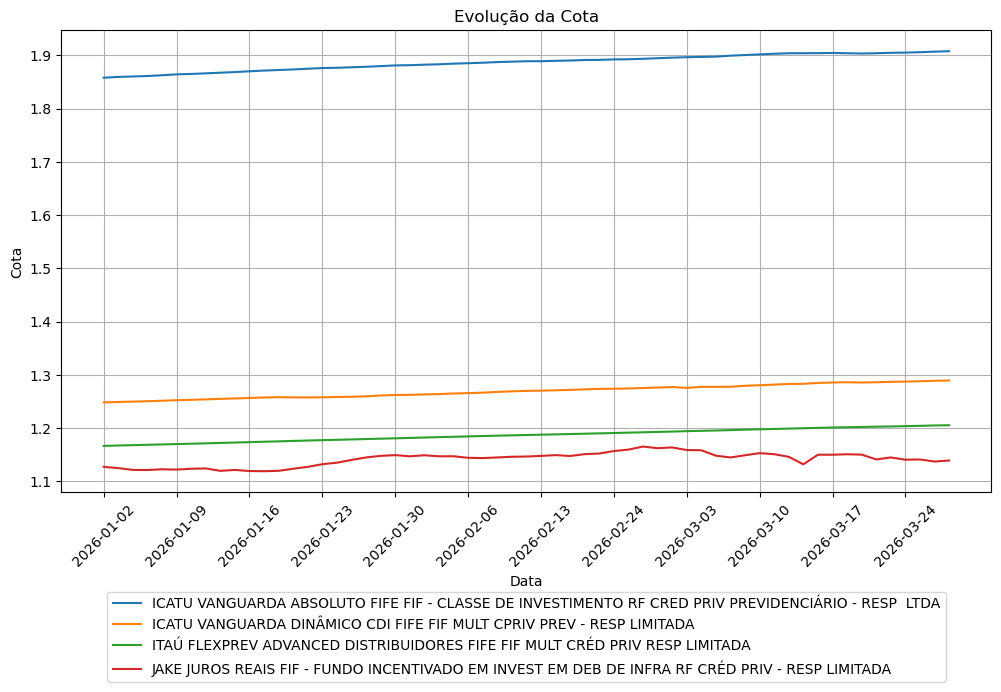

In [57]:
#Evolução da cota (não normalizada)
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["VL_QUOTA"], label=fundo)

plt.title("Evolução da Cota")
plt.xlabel("Data")
plt.ylabel("Cota")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

#### Comentário:
A evolução da cota apresenta baixa volatilidade, comportamento típico de fundos de crédito privado, onde o retorno tende a ser mais linear e menos sujeito a oscilações abruptas, diferentemente de ativos de renda variável.

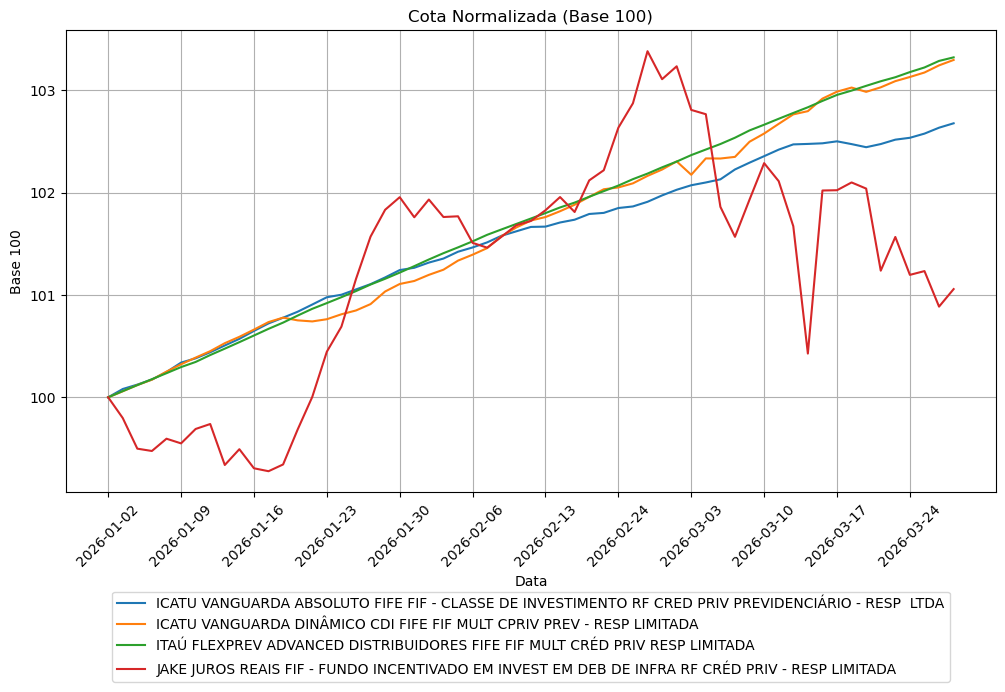

In [58]:
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["COTA_BASE_100"], label=fundo)

plt.title("Cota Normalizada (Base 100)")
plt.xlabel("Data")
plt.ylabel("Base 100")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

#### Comentário:
Normalizando o valor da cota, notamos maior oscilação ao longo do período para o fundo JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM INVEST EM DEB DE INFRA RD CRÉD PRIV - RESP LIMITADA, que foi classificado como fundo com perfil mais conservador. Esse resultado pode indicar, por exemplo, títulos sensíveis a juros, ou também concentração elevada, note que na tabela "Perfil mais conservador - Icatu Vanguarda x Concorrente mais próximo" o valor de concentração normalizado (CONC_NORM) é mais próximo dos fundos do perfil mais arriscado. O dois fundo classificados como fundo com perfil mais arriscado apresentam evolução estável e consistente, enquanto o fundo da Icatu Vaguarda mais conservador, um crescimento gradual.

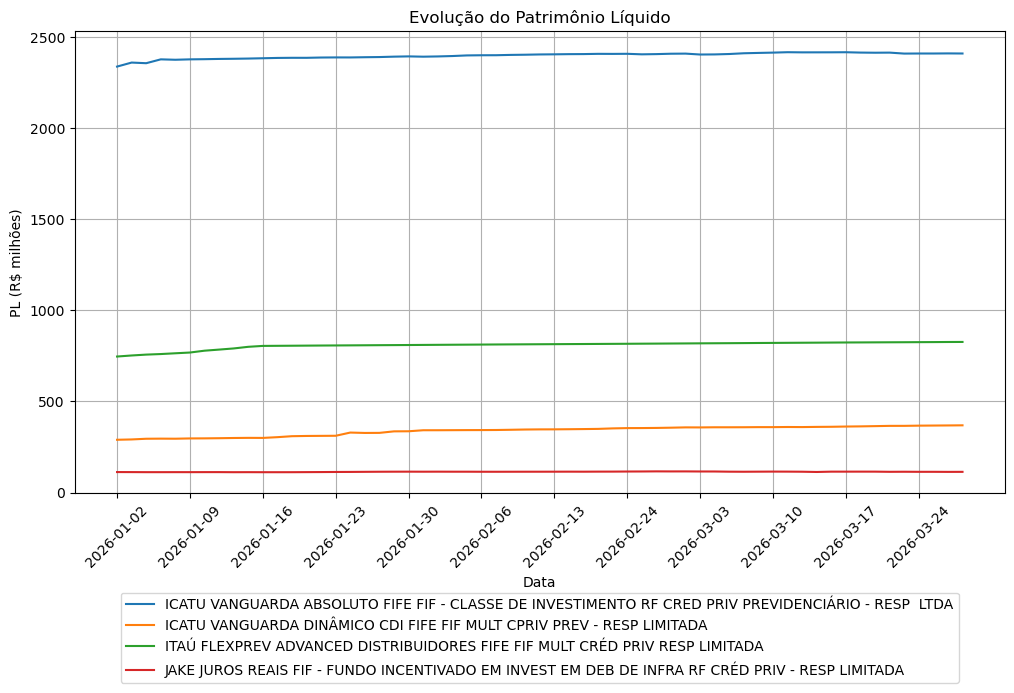

In [59]:
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["VL_PATRIM_LIQ"] / 1e6, label=fundo)

plt.title("Evolução do Patrimônio Líquido")
plt.xlabel("Data")
plt.ylabel("PL (R$ milhões)")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

#### Comentário:
Os quatro fundos apresentam crescimento consistente no período, indicando captação líquida positiva ou valorização dos ativos. 
Vale destacar uma análise conjunta entre o presente gráfico e o de cotas normalizadas. Esse cruzamento pode indicar um fundo robusto operacionalmente, diversificado e estável na geração do retorno. Para isso, é necessário volume de PL elevado e valor de cota consistente, o fundo de perfil conservador da Icatu Vaguarda atende a esses critérios.

In [60]:
# Resumo em tabela
df_resumo_4 = (
    df_inf.groupby(["CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL"])
          .agg(
              DATA_INICIO=("DT_COMPTC", "min"),
              DATA_FIM=("DT_COMPTC", "max"),
              COTA_INICIAL=("VL_QUOTA", "first"),
              COTA_FINAL=("VL_QUOTA", "last"),
              PL_INICIAL=("VL_PATRIM_LIQ", "first"),
              PL_FINAL=("VL_PATRIM_LIQ", "last"),
              PL_MEDIO=("VL_PATRIM_LIQ", "mean"),
              VOLATILIDADE_DIARIA=("RETORNO_DIARIO", "std")
          )
          .reset_index()
)

# Métricas derivadas
## retorno no período
df_resumo_4["RETORNO_PERIODO"] = (
    df_resumo_4["COTA_FINAL"] / df_resumo_4["COTA_INICIAL"] - 1
)

df_resumo_4["VARIACAO_PL_PERIODO"] = (
    df_resumo_4["PL_FINAL"] / df_resumo_4["PL_INICIAL"] - 1
)
df_resumo_4 = df_resumo_4.sort_values("RETORNO_PERIODO", ascending=False).reset_index(drop=True)

df_resumo_exibicao = df_resumo_4.copy()

for col in ["RETORNO_PERIODO", "VARIACAO_PL_PERIODO", "VOLATILIDADE_DIARIA"]:
    df_resumo_exibicao[col] = df_resumo_exibicao[col].apply(
        lambda x: f"{x:.2%}" if pd.notnull(x) else None
    )

df_resumo_exibicao["COTA_INICIAL"] = df_resumo_exibicao["COTA_INICIAL"].round(6)
df_resumo_exibicao["COTA_FINAL"] = df_resumo_exibicao["COTA_FINAL"].round(6)
df_resumo_exibicao["PL_MEDIO"] = df_resumo_exibicao["PL_MEDIO"].round(2)

#### Resumo performance do fundo

In [61]:
df_resumo_exibicao

,CNPJ_FUNDO_CLASSE,DENOM_SOCIAL,DATA_INICIO,DATA_FIM,COTA_INICIAL,COTA_FINAL,PL_INICIAL,PL_FINAL,PL_MEDIO,VOLATILIDADE_DIARIA,RETORNO_PERIODO,VARIACAO_PL_PERIODO
0,58.013.738/0001-73,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,2026-01-02,2026-03-27,1.166803,1.205580,7.469290e+08,8.270020e+08,8.087698e+08,0.01%,3.32%,10.72%
1,53.444.176/0001-07,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,2026-01-02,2026-03-27,1.248482,1.289655,2.898571e+08,3.691876e+08,3.385091e+08,0.04%,3.30%,27.37%
2,34.081.211/0001-18,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,2026-01-02,2026-03-27,1.858070,1.907842,2.338983e+09,2.410838e+09,2.398828e+09,0.03%,2.68%,3.07%
3,54.834.372/0001-42,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,2026-01-02,2026-03-27,1.127394,1.139320,1.125408e+08,1.137312e+08,1.139638e+08,0.39%,1.06%,1.06%


#### Comentário:

Os fundos ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES e ICATU VANGUARDA DINÂMICO CDI apresentaram os melhores desempenhos no período analisado, com retornos de 3,32% e 3,30%, respectivamente, superando os demais fundos da amostra.

Além do nível de retorno, observa-se que o desempenho do fundo Icatu Dinâmico CDI ocorreu de forma mais consistente ao longo do período, com menor oscilação relativa, enquanto outros fundos apresentaram trajetórias mais irregulares. Esse comportamento sugere uma relação risco-retorno mais eficiente no caso do fundo da Icatu.

Em relação ao crescimento do patrimônio líquido, o fundo Icatu Vanguarda Iporã apresentou a maior variação no período (+128%), o que indica forte expansão de ativos sob gestão. Esse movimento pode estar associado principalmente à captação líquida positiva, possivelmente impulsionada pela atratividade recente do fundo ou por estratégias comerciais, e não necessariamente apenas pela performance dos ativos.

Por outro lado, o fundo KBROTHERS apresentou a maior volatilidade entre os fundos analisados, evidenciando maior oscilação no valor da cota ao longo do tempo. Em fundos de crédito privado, esse comportamento pode estar relacionado a uma carteira com maior exposição a ativos de risco, maior duration ou maior sensibilidade à marcação a mercado, refletindo possíveis variações nos spreads de crédito.

De forma consolidada, os resultados indicam diferentes perfis de gestão entre os fundos: enquanto alguns apresentam maior estabilidade e consistência de retorno, outros assumem maior risco em busca de retornos potencialmente superiores, o que se reflete em maior volatilidade.

Essa análise inicial de performance será aprofundada na próxima etapa por meio da avaliação da composição das carteiras, permitindo entender os drivers de risco e retorno observados.

# Composição da carteira

A análise da composição da carteira foi realizada a partir das posições em debêntures extraídas do CDA, enriquecidas com informações cadastrais dos ativos. Foram calculadas métricas de concentração por emissor, distribuição por indexador e prazo médio ponderado, permitindo avaliar o nível de diversificação e o perfil de risco dos fundos.

In [62]:
# Importar os dados do arquivo de Debêntures
df_deb = pd.read_csv(
    diretorio_dados / arquivo_deb,
    sep="\t",
    encoding="latin1",
    decimal=",",
    skiprows=4,
    header = 0)
df_deb.columns = df_deb.columns.str.strip()

## Colunas de interesse do arquivo de debêntures
colunas_deb_uteis = [
    "ISIN",
    "Codigo do Ativo",
    "Empresa",
    "Situacao",
    "Data de Emissao",
    "Data de Vencimento",
    "Garantia/Especie",
    "Classe",
    "indice",
    "Percentual Multiplicador/Rentabilidade",
    "CNPJ"]

df_deb_aux = df_deb[colunas_deb_uteis].copy()
df_deb_aux = df_deb_aux.rename(columns={
    "ISIN": "CD_ISIN",
    "Codigo do Ativo": "CODIGO_ATIVO",
    "Empresa": "EMISSOR_DEB",
    "Situacao": "SITUACAO",
    "Data de Emissao": "DATA_EMISSAO",
    "Data de Vencimento": "DATA_VENCIMENTO",
    "Garantia/Especie": "GARANTIA_ESPECIE",
    "Classe": "CLASSE",
    "indice": "INDEXADOR",
    "Percentual Multiplicador/Rentabilidade": "PERCENTUAL_RENTABILIDADE",
    "CNPJ": "CNPJ_EMISSOR"})

df_cda_deb_4 = df_cda_4.merge(df_deb_aux, how = "left", on = "CD_ISIN")

## alterando o tipo do dado
df_cda_deb_4["VL_MERC_POS_FINAL"] = pd.to_numeric(df_cda_deb_4["VL_MERC_POS_FINAL"], errors="coerce")

## O quanto o valor total investido em debêntures no fundo no mês representa dentro da carteira
df_cda_deb_4["VALOR_TOTAL"] = (df_cda_deb_4.groupby(["CNPJ_FUNDO_CLASSE", "PERIODO"])["VL_MERC_POS_FINAL"].transform("sum"))
df_cda_deb_4["PESO"] = (df_cda_deb_4["VL_MERC_POS_FINAL"] / df_cda_deb_4["VALOR_TOTAL"])

In [63]:
## COMPOSIÇÃO POR EMISSOR
df_cda_deb_4_emissor = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO", "EMISSOR_DEB"])["PESO"]
               .sum()
               .reset_index()
)

# Top emissores:
df_top_cda_deb_4_emissor = (
    df_cda_deb_4_emissor.sort_values(["DENOM_SOCIAL", "PERIODO", "PESO"], ascending=False)
              .groupby(["DENOM_SOCIAL", "PERIODO"])
              .head(5)
)

# Concentração em 5 maiores emissores
df_concentracao_cda_deb_4_emissor = (
    df_top_cda_deb_4_emissor.groupby(["DENOM_SOCIAL", "PERIODO"])["PESO"]
          .sum()
          .reset_index(name="TOP5_CONCENTRACAO")
)


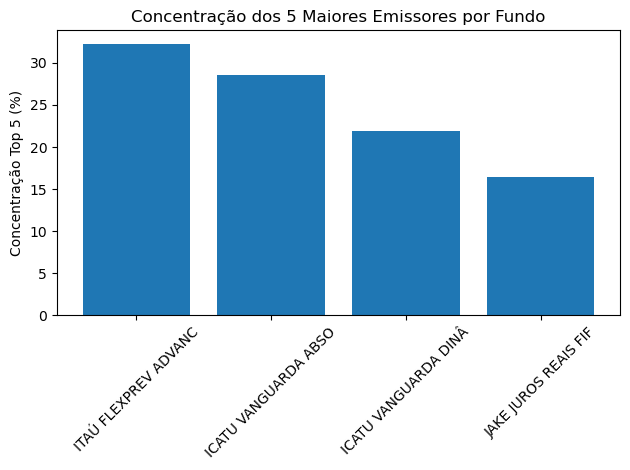

In [64]:
## Analisando para um período comum a todos
df_plot_concentracao_cda_deb_4_emissor = df_concentracao_cda_deb_4_emissor.copy()
df_plot_concentracao_cda_deb_4_emissor = df_plot_concentracao_cda_deb_4_emissor[df_plot_concentracao_cda_deb_4_emissor["PERIODO"] == "202506"]
df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"] = df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"] * 100
df_plot_concentracao_cda_deb_4_emissor = df_plot_concentracao_cda_deb_4_emissor.sort_values("TOP5_CONCENTRACAO", ascending=False)
df_plot_concentracao_cda_deb_4_emissor["NOME_CURTO"] = df_plot_concentracao_cda_deb_4_emissor["DENOM_SOCIAL"].str[:20]

plt.figure()
plt.bar(df_plot_concentracao_cda_deb_4_emissor["NOME_CURTO"], df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"])
plt.xticks(rotation = 45)
plt.ylabel("Concentração Top 5 (%)")
plt.title("Concentração dos 5 Maiores Emissores por Fundo")
plt.tight_layout()
plt.show()

#### Comentário:

O gráfico apresentado tem como objetivo avaliar o nível de concentração de risco nos cinco maiores emissores de cada fundo.
No grupo de fundos com perfil mais conservador, o Icatu Vanguarda Absoluto apresenta maior concentração em comparação ao seu concorrente (Jake Juros), indicando uma carteira mais exposta a poucos emissores. Já entre os fundos de perfil mais arriscado, observa-se que o fundo do Itaú possui maior concentração nos cinco principais emissores quando comparado ao Icatu Vanguarda Dinâmico. Além disso, ao comparar os fundos da própria Icatu, nota-se que o Icatu Vanguarda Dinâmico apresenta menor concentração em relação ao Icatu Vanguarda Absoluto, indicando uma carteira relativamente mais diversificada dentro do perfil mais arriscado comparado ao candidato mais conservador.

In [ ]:
# Classificando setorialmente as debêntures
df_cda_deb_4["SETOR_EMISSOR_DEB"] = df_cda_deb_4["EMISSOR_DEB"].apply(classificar_setor)
df_setor = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO", "SETOR_EMISSOR_DEB"])["PESO"]
               .sum()
               .reset_index()
)

## Limitando a um período específico, comum a maioria e mais recente possível: 202506
df_setor_202506 = df_setor[df_setor["PERIODO"] == "202506"].copy()

## Agrupando setores com pouca exposição em Outros
df_setor_202506["SETOR_AJUSTADO"] = df_setor_202506["SETOR_EMISSOR_DEB"].where(
    df_setor_202506["PESO"] >= 0.05,
    "Outros")

df_setor_resumo = (
    df_setor_202506
    .groupby(["DENOM_SOCIAL", "PERIODO", "SETOR_AJUSTADO"])["PESO"]
    .sum()
    .reset_index())

df_setor_resumo_pivot = df_setor_resumo.pivot_table(
    index="DENOM_SOCIAL",
    columns="SETOR_AJUSTADO",
    values="PESO",
    fill_value=0
).reset_index()

#### Classificação setorial das debêntures

In [73]:
df_setor_resumo_pivot

SETOR_AJUSTADO,DENOM_SOCIAL,Energia,Infraestrutura,Logística,Outros,Saneamento,Saúde,Telecom
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,0.199117,0.054472,0.000000,0.493431,0.065533,0.130467,0.056979
1,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,0.190512,0.081124,0.053206,0.411905,0.122036,0.089606,0.051612
2,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,0.172016,0.000000,0.136137,0.630700,0.000000,0.061148,0.000000
3,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,0.273050,0.125731,0.000000,0.482492,0.059382,0.000000,0.059345


#### Comentário:

Para complementar a análise por emissor, foi construída uma classificação setorial dos emissores com base em regras heurísticas aplicadas aos nomes das empresas, permitindo analisar a exposição econômica das carteiras e identificar possíveis concentrações por setor.

Dessa forma, observou-se maior concentração na categoria “Outros”, que agrega setores com menor representatividade individual, mas que, em conjunto, se tornam relevantes. Ainda assim, é possível identificar o setor de "Energia" como o principal segmento de alocação entre os quatro fundos analisados.

Obervando os setores subsequentes, nota-se diferenciação entre os perfis de risco: nos fundos com perfil mais arriscado, destacam-se setores como "Saneamento" e "Logística", enquanto nos fundos de perfil mais conservador, maior presença em "Saúde" e "Infraestrutura". Essa distinção sugere diferentes estratégias de alocação e perfis de risco de crédito entre os fundos.

In [67]:
# Indexador: IPCA e CDI ou Não informado
df_cda_deb_4["INDEXADOR_CLASSE"] = df_cda_deb_4["DS_INDEXADOR_POSFX"].apply(classificar_indexador)
df_indexador_cda_deb_4 = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO", "INDEXADOR_CLASSE"])["PESO"]
               .sum()
               .reset_index()
)
df_indexador_cda_deb_4_pivot = df_indexador_cda_deb_4.pivot_table(
    index=["DENOM_SOCIAL", "PERIODO"],
    columns="INDEXADOR_CLASSE",
    values="PESO",
    fill_value=0
).reset_index()

## Seleção do período que contém valor para todos os 4 fundos
df_indexador_cda_deb_4_pivot_202506 = df_indexador_cda_deb_4_pivot[df_indexador_cda_deb_4_pivot["PERIODO"] == "202506"].copy()

#### Exposição por indexador tradicional

In [68]:
df_indexador_cda_deb_4_pivot_202506

INDEXADOR_CLASSE,DENOM_SOCIAL,PERIODO,CDI,IPCA,NÃO INFORMADO
1,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,202506,0.137096,0.115106,0.747798
3,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,202506,0.136366,0.049598,0.814036
5,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202506,0.167900,0.000000,0.832100
9,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202506,0.071041,0.056453,0.872506


#### Comentário:

Ao analisar por indexador, observou-se baixa representatividade de CDI e IPCA no período de junho de 2026, indicando que o retorno desses quatro fundos pode estar atrelado às característica de crédito do ativo e não pela variação direta de CDI ou inflação. Nesse sentido, será feito mais adiante uma análise envolvendo spread e prazo médio ponderado.

In [51]:
### Anbima importar dados
df_anbima = pd.read_csv(
    diretorio_dados / arquivo_anbima,
    sep=";",
    encoding="latin1",
    decimal=","
)

#conversão para data, pois precisamos criar o período para relacionar com df_cda_deb_4
df_anbima["data"] = pd.to_datetime(df_anbima["data"])


df_anbima["PERIODO"] = df_anbima["data"].dt.year * 100 + df_anbima["data"].dt.month


In [54]:
#valor mais recente para cada período

df_anbima_mes= df_anbima.rename(columns={
    "codigo": "CD_ATIVO"
})

In [55]:
df_anbima_mes["CD_ATIVO"]

0         ACRC21        
1         AEAB11        
2         AEGP23        
3         AESL17        
4         AESLA5        
               ...      
347122    MULP17        
347123    RADL14        
347124    SAPR29        
347125    TAEE16        
347126    UNDAC3        
Name: CD_ATIVO, Length: 347127, dtype: object

In [56]:
df_cda_deb_4["PERIODO"] = pd.to_numeric(df_cda_deb_4["PERIODO"], errors="coerce")
df_anbima_mes["PERIODO"] = pd.to_numeric(df_anbima_mes["PERIODO"], errors="coerce")
df_anbima_mes["CD_ATIVO"] = df_anbima_mes["CD_ATIVO"].str.strip()

df_cda_deb_4 = df_cda_deb_4.merge(
    df_anbima_mes[["CD_ATIVO", "PERIODO", "spread", "duration"]],
    how="left",
    on=["CD_ATIVO", "PERIODO"]
)

In [57]:
## significa que não temos dados anbima para o período que temos na carteira mais recente
df_cda_deb_4["spread"].isna().mean(), df_cda_deb_4["duration"].isna().mean()

(np.float64(0.03248246844319776), np.float64(0.03248246844319776))

In [58]:
df_cda_deb_4["spread"] = pd.to_numeric(
    df_cda_deb_4["spread"],
    errors="coerce")

df_cda_deb_4["duration"] = pd.to_numeric(
    df_cda_deb_4["duration"],
    errors="coerce")
#Spread médio ponderado
#df_spread = (
#    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO"])
#               .apply(lambda x: (x["spread"] * x["PESO"]).sum())
#               .reset_index(name="spread_medio"))
df_cda_deb_4["spread_pond"] = df_cda_deb_4["spread"] * df_cda_deb_4["PESO"]
df_spread = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO"])["spread_pond"]
    .sum()
    .reset_index(name="spread_medio")
)
#duration média ponderada
#df_duration = (
#    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO"])
#               .apply(lambda x: (x["duration"] * x["PESO"]).sum())
#               .reset_index(name="duration_media"))

df_cda_deb_4["duration_pond"] = df_cda_deb_4["duration"] * df_cda_deb_4["PESO"]
df_duration = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO"])["duration_pond"]
    .sum()
    .reset_index(name="duration_media")
)
df_risco = df_spread.merge(df_duration, on=["DENOM_SOCIAL", "PERIODO"])

📊 Spread
maior → mais risco de crédito
menor → mais conservador
📊 Duration
maior → mais sensível a juros
menor → mais defensivo
📊 Junto com o resto:

Você cruza com:

concentração
setor
indexador

👉 e vira análise de asset

In [59]:
df_risco.sort_values(["PERIODO", "DENOM_SOCIAL"])

,DENOM_SOCIAL,PERIODO,spread_medio,duration_media
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,202501,48.342028,59.689569
2,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,202501,49.804982,58.208056
4,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202501,28.052435,48.581305
8,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202501,7.505098,99.219535
1,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,202506,21.917184,39.812753
3,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,202506,20.354684,48.101881
5,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202506,17.640917,45.516949
9,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202506,5.986820,87.327632
6,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202601,18.340443,68.813189
10,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202601,4.532833,104.393421


2. Entender o que cada métrica quer dizer
Spread médio ponderado
maior spread → carteira exigindo prêmio maior
normalmente indica maior risco de crédito ou ativos menos óbvios / menos líquidos
menor spread → carteira mais conservadora
Duration média ponderada
maior duration → maior sensibilidade à curva de juros
menor duration → carteira mais defensiva
Como interpretar a combinação das duas

Essa parte é muito boa no case.

Cenário A — spread alto + duration alta

Fundo mais agressivo:

mais risco de crédito
mais risco de taxa
Cenário B — spread alto + duration baixa
busca prêmio de crédito
mas sem alongar tanto prazo
Cenário C — spread baixo + duration alta
menos prêmio de crédito
mas mais risco de juros
Cenário D — spread baixo + duration baixa
perfil mais conservador